In [501]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_predict,  StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
import os


filename = "Reto_2_AFM.ipynb"  # Current file name
#print(f"Current file name: {filename}\n")
#print(f"Current absolute path: {os.getcwd()}\n")

# Specify the paths, relative to the current file
ACTUAL_DIR = os.path.dirname(os.path.abspath(filename))
BASE_DIR = os.path.dirname(ACTUAL_DIR)
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(DATA_DIR, "output_data")

#print(f"BASE_DIR: {BASE_DIR}")
#print(f"DATA_DIR: {DATA_DIR}")
#print(f'OUTPUT_DIR: {OUTPUT_DIR}')

# The HISTORICO_SUERTES.xlsx should be in the data directory
df_base = pd.read_excel(os.path.join(DATA_DIR, "BD_IPSA_1940.xlsx"))

# First, lets modify the column names
df_base.columns = [
    x.lower()
    .strip()
    .replace(" ", "_")
    .replace(".", "_")
    .replace("-", "_")
    .replace("(", "")
    .replace(")", "")
    .replace("%", "pct_")
    for x in df_base.columns
]

df_base.head(5)




,unnamed:_0,nome,faz,tal,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,tch,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


In [502]:
# Cargar el dataset
df = df_base.copy()#pd.read_excel("/data/BD_IPSA_1940.xlsx")
df.shape

(2187, 21)

In [503]:

# Selección de columnas relevantes
columns_to_keep = ["dosismad","semsmad", "edad", "cortes", "sacarosa", "tch", "lluvias",  "pct_diatrea","mes","me","grupo_tenencia"]

#columns_to_keep = ["dosismad","semsmad", "edad", "cortes", "sacarosa", "tch", "lluvias",  "pct_diatrea"]


#"grupo_tenencia" 
df = df[columns_to_keep]

# Análisis de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
dosismad          0
semsmad           0
edad              0
cortes            0
sacarosa          0
tch               0
lluvias           0
pct_diatrea       0
mes               0
me                0
grupo_tenencia    0
dtype: int64


In [504]:
# Columnas requeridas
columnas_OneHot = {'mes', 'grupo_tenencia'}

# Verificar si las columnas están presentes en el DataFrame
if columnas_OneHot.issubset(df.columns):
    lista=['mes', 'grupo_tenencia']
    # Convertir a tipo categórico
    df[lista] = df[lista].astype('category')
    print(df.dtypes)
    #df_dummies = pd.get_dummies(df.drop(columns=['tch_category', 'sacarosa_category']),drop_first=True)
    df = pd.get_dummies(df, columns=['mes', 'grupo_tenencia'], drop_first=True)

    #print(df_dummies.head())
    print(df.columns)



dosismad           float64
semsmad            float64
edad               float64
cortes               int64
sacarosa           float64
tch                  int64
lluvias              int64
pct_diatrea        float64
mes               category
me                 float64
grupo_tenencia    category
dtype: object
Index(['dosismad', 'semsmad', 'edad', 'cortes', 'sacarosa', 'tch', 'lluvias',
       'pct_diatrea', 'me', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6',
       'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12',
       'grupo_tenencia_2', 'grupo_tenencia_3'],
      dtype='object')


<Figure size 1200x600 with 0 Axes>

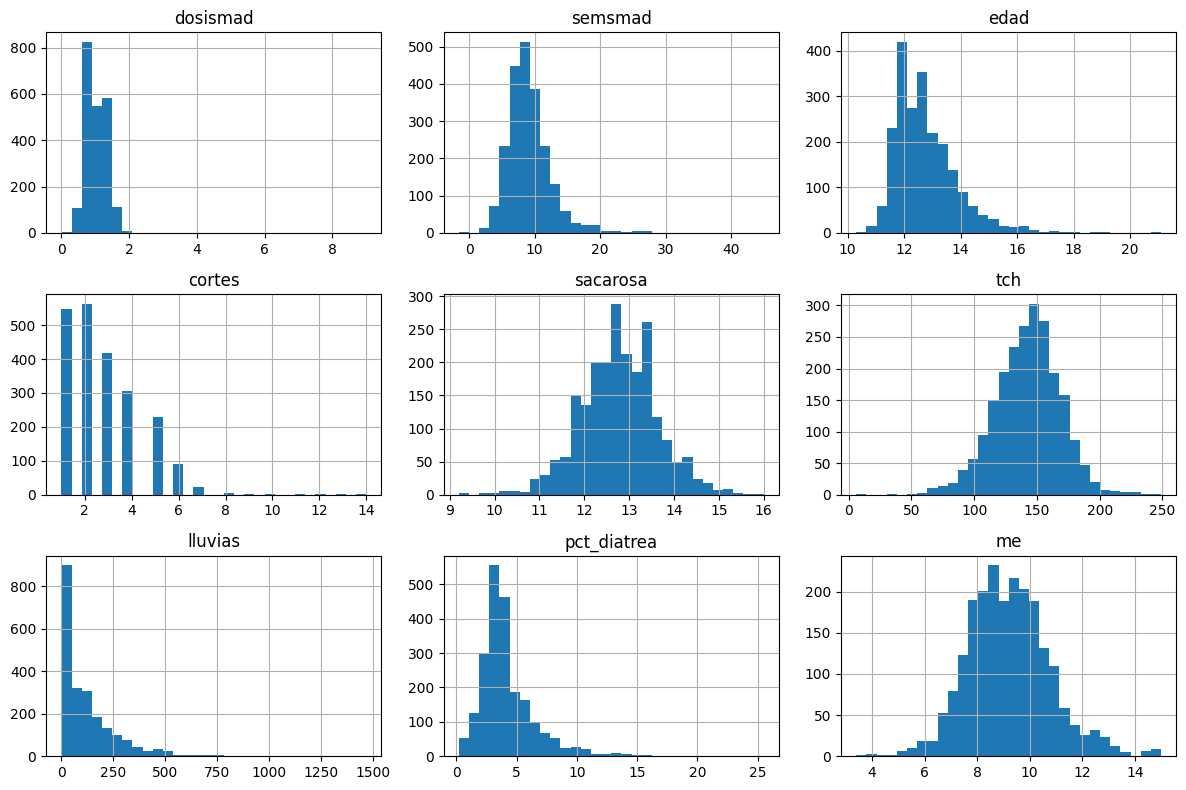

In [505]:
# Análisis de la distribución de variables
plt.figure(figsize=(12, 6))
df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()



In [506]:
# Análisis de percentiles para TCH y Sacarosa
percentiles = [0, 5,10, 25, 50, 75, 90, 95,100]
percentile_values = df[['sacarosa', 'tch']].quantile([p/100 for p in percentiles])
print("Percentiles para TCH y Sacarosa:")
print(percentile_values)

Percentiles para TCH y Sacarosa:
      sacarosa    tch
0.00       9.2    6.0
0.05      11.4   99.0
0.10      11.7  110.0
0.25      12.2  126.0
0.50      12.8  144.0
0.75      13.3  159.0
0.90      13.8  174.0
0.95      14.2  182.7
1.00      16.0  249.0


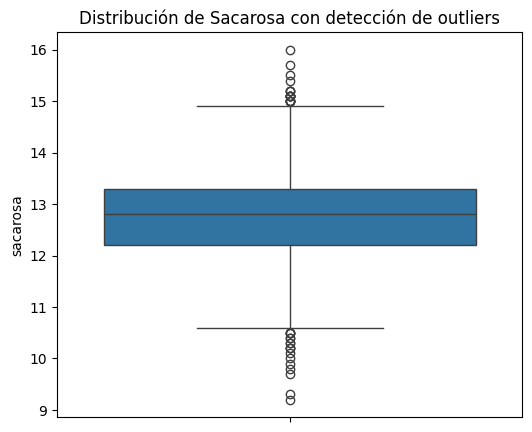

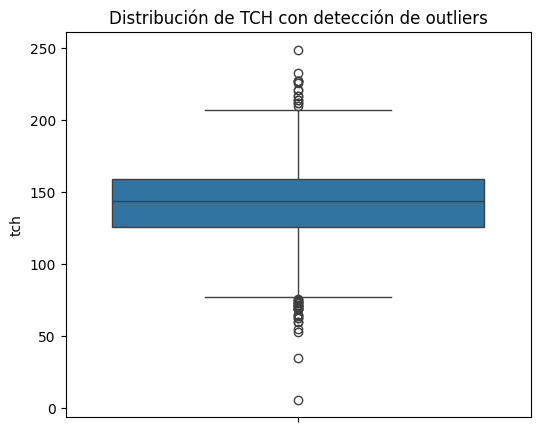

In [507]:
# Gráficos de las variables dependientes en gráficos separados
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['sacarosa'])
plt.title("Distribución de Sacarosa con detección de outliers")
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(y=df['tch'])
plt.title("Distribución de TCH con detección de outliers")
plt.show()

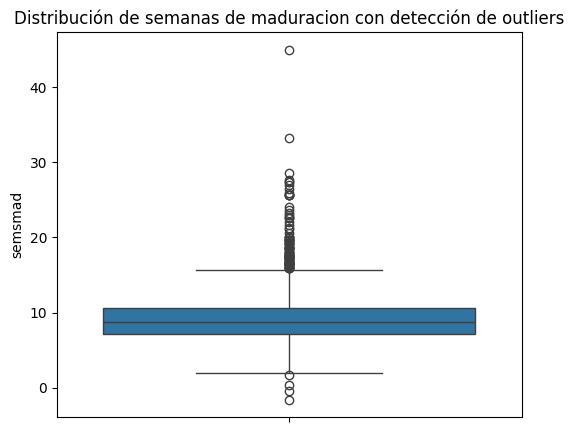

Percentiles para semsmad:
      semsmad
0.00    -1.60
0.05     5.00
0.10     5.70
0.25     7.10
0.50     8.70
0.75    10.60
0.90    12.94
0.95    14.84
1.00    45.00


In [508]:
# Gráficos de las variables dependientes en gráficos separados
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['semsmad'])
plt.title("Distribución de semanas de maduracion con detección de outliers")
plt.show()

percentiles = [0, 5,10, 25, 50, 75, 90,95, 100]
percentile_values = df[['semsmad']].quantile([p/100 for p in percentiles])
print("Percentiles para semsmad:")
print(percentile_values)

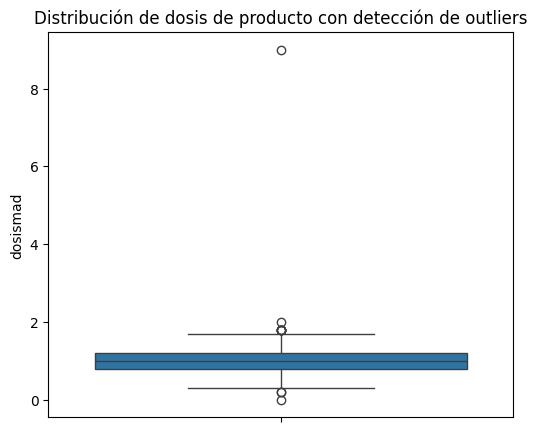

Percentiles para dosismad:
      dosismad
0.00      0.00
0.05      0.53
0.10      0.80
0.25      0.80
0.50      1.00
0.75      1.20
0.90      1.30
0.95      1.50
1.00      9.00


In [509]:
# Gráficos de las variables dependientes en gráficos separados
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['dosismad'])
plt.title("Distribución de dosis de producto con detección de outliers")
plt.show()

percentiles = [0, 5,10, 25, 50, 75, 90,95, 100]
percentile_values = df[['dosismad']].quantile([p/100 for p in percentiles])
print("Percentiles para dosismad:")
print(percentile_values)

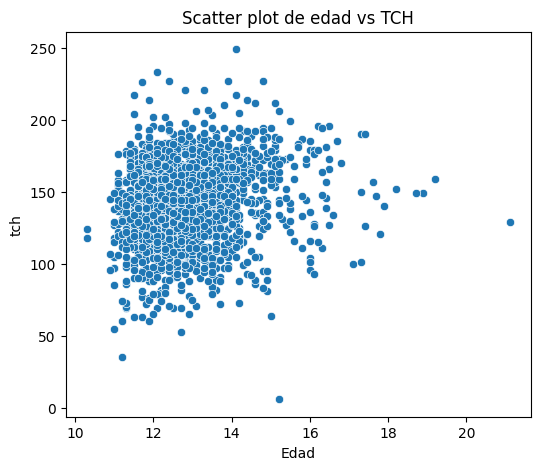

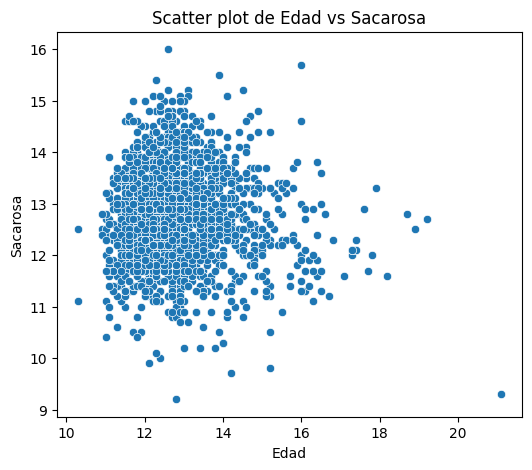

In [510]:
# Scatter plots de vejez vs TCH y Sacarosa
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['edad'], y=df['tch'])
plt.xlabel("Edad")
plt.ylabel("tch")
plt.title("Scatter plot de edad vs TCH")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['edad'], y=df['sacarosa'])
plt.xlabel("Edad")
plt.ylabel("Sacarosa")
plt.title("Scatter plot de Edad vs Sacarosa")
plt.show()

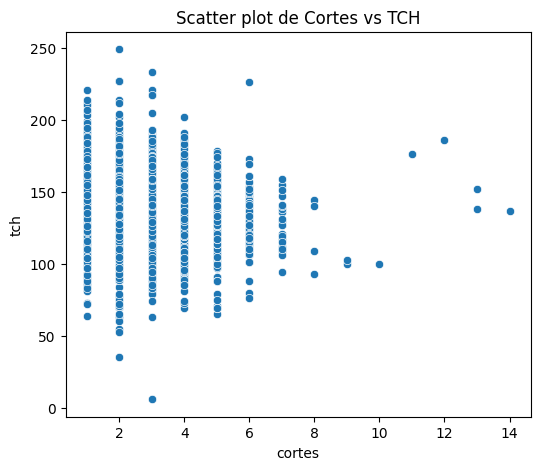

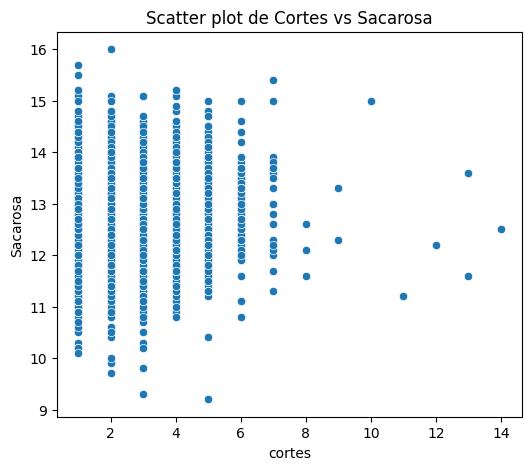

In [511]:
# Scatter plots de vejez vs TCH y Sacarosa
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['cortes'], y=df['tch'])
plt.xlabel("cortes")
plt.ylabel("tch")
plt.title("Scatter plot de Cortes vs TCH")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['cortes'], y=df['sacarosa'])
plt.xlabel("cortes")
plt.ylabel("Sacarosa")
plt.title("Scatter plot de Cortes vs Sacarosa")
plt.show()

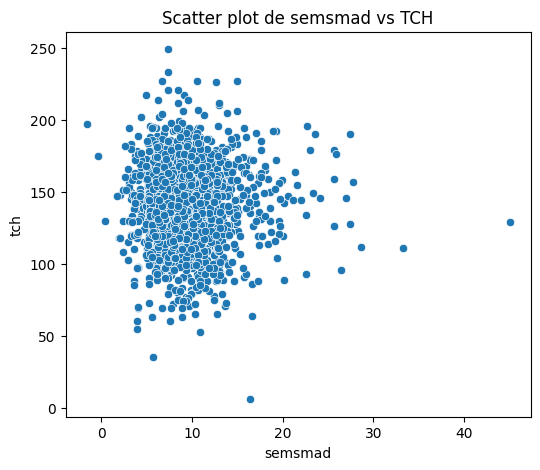

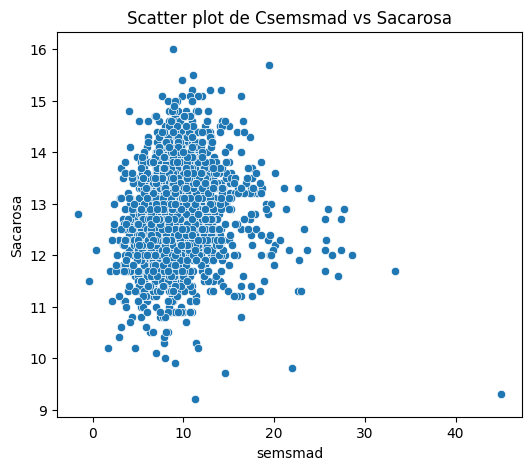

In [512]:
# Scatter plots de vejez vs TCH y Sacarosa
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['semsmad'], y=df['tch'])
plt.xlabel("semsmad")
plt.ylabel("tch")
plt.title("Scatter plot de semsmad vs TCH")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(x=df['semsmad'], y=df['sacarosa'])
plt.xlabel("semsmad")
plt.ylabel("Sacarosa")
plt.title("Scatter plot de Csemsmad vs Sacarosa")
plt.show()

In [513]:
# Detección de outliers usando el método IQR
for col in ['sacarosa', 'tch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Número de outliers en {col}: {len(outliers)}")

Número de outliers en sacarosa: 37
Número de outliers en tch: 42


In [514]:

# Rellenar valores nulos con la media de cada columna
#df.fillna(df.mean(), inplace=True)

# Eliminar valores outliers en la columna 'semsmad'
# Limmpieza de Outliers para variable semsmad
df = df[(df['semsmad'] >= 5) & (df['semsmad'] <= 14.84)] #Conserva Mayor a Percentil 5 y menor a percentil 95
# Limpieza de Outliers para variable TCH
df = df[(df['tch'] <= 182) & (df['tch'] >= 40)] # Conserva Menor a Percentil 95
# Limpieza de Outliers para variable cortes
df = df[(df['cortes'] <= 8)] #  En Colombia, muchas plantaciones comerciales suelen resembrarse tras 5 a 7 cortes, dependiendo del rendimiento y costos de producción.Se toma como valor maximo 8 cortes.
# Limpieza de Outliers de variable dosismad
df = df[(df['dosismad'] > 0) & (df['dosismad'] <= 1.5)] # Conserva Menor a percentil 95 y mayor a 0



In [515]:
# Detección de outliers usando el método IQR
for col in ['sacarosa', 'tch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Número de outliers en {col}: {len(outliers)}")

Número de outliers en sacarosa: 24
Número de outliers en tch: 21


In [516]:
df.shape

(1847, 22)

In [517]:
# Crear variables categóricas para TCH y Sacarosa
# Se realiza investigación de que porcentajes son normales para el TCH y se observa que la media mundial es de 60, pero la media de colombia esta en 120. Por lo que 
# decidimos realizar la categorización con percentiles y aque no encontramos valores de referencia para COlombia. de 0 a percentil 25 es bajo, de percentil 25 a 75 es medio y por encima de percentil 
# 75 es alto
df['tch_category'] = pd.cut(df['tch'], bins=[-float('inf'), 126, 159, float('inf')], labels=['bajo', 'normal', 'alto'])
# Decidimos realizar la categorización con percentiles ya que no encontramos valores de referencia para Colombia. de 0 a percentil 25 es bajo, de percentil 25 a 75 es medio y por encima de percentil 
# 75 es alto
df['sacarosa_category'] = pd.cut(df['sacarosa'], bins=[-float('inf'), 12.2, 13.3, float('inf')], labels=['bajo', 'normal', 'alto'])


In [518]:
df.columns

Index(['dosismad', 'semsmad', 'edad', 'cortes', 'sacarosa', 'tch', 'lluvias',
       'pct_diatrea', 'me', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6',
       'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12',
       'grupo_tenencia_2', 'grupo_tenencia_3', 'tch_category',
       'sacarosa_category'],
      dtype='object')

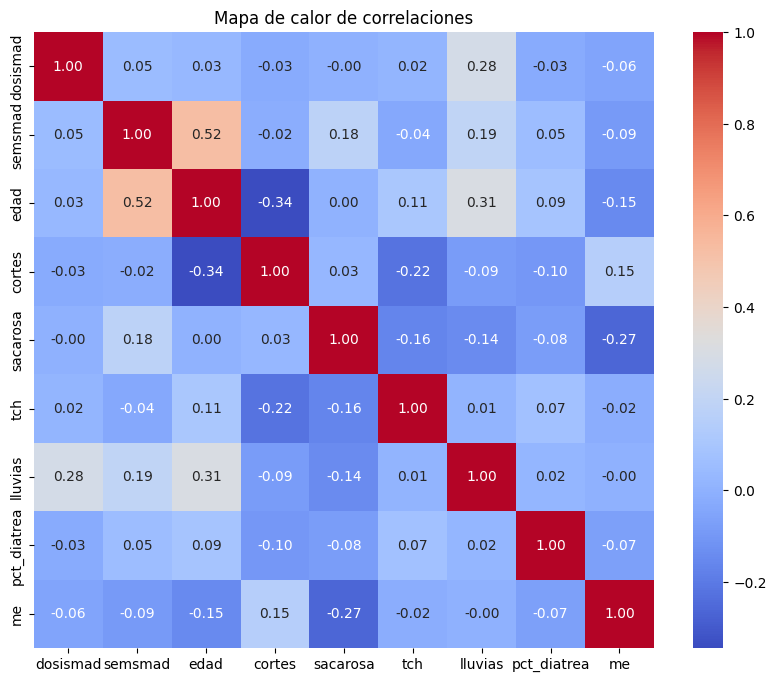

In [519]:
# Análisis de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()



In [520]:
# Variables dependientes y predictoras
X = df.drop(columns=["sacarosa", "tch", "sacarosa_category", "tch_category"])
y_sacarosa = df["sacarosa_category"]
y_TCH = df["tch_category"]



In [521]:
X.head()

,dosismad,semsmad,edad,cortes,lluvias,pct_diatrea,me,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,grupo_tenencia_2,grupo_tenencia_3
0,0.8,8.3,12.3,4,137,6.2,12.7,False,False,False,False,False,False,False,False,False,False,True,False,True
1,0.8,6.3,11.2,2,0,3.5,7.8,False,True,False,False,False,False,False,False,False,False,False,False,True
2,0.6,7.9,12.2,3,68,4.3,8.8,False,True,False,False,False,False,False,False,False,False,False,False,True
3,0.8,6.6,13.1,1,0,3.5,6.1,False,True,False,False,False,False,False,False,False,False,False,False,True
4,0.6,8.1,12.2,2,68,4.3,7.9,False,True,False,False,False,False,False,False,False,False,False,False,True


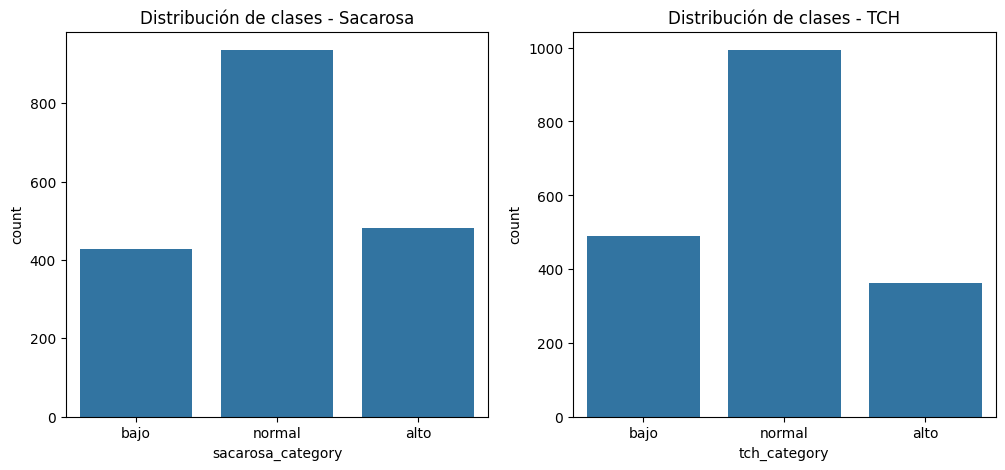

In [522]:
# Graficar la distribución de clases para cada variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_sacarosa, ax=axes[0])
axes[0].set_title('Distribución de clases - Sacarosa')

sns.countplot(x=y_TCH, ax=axes[1], )
axes[1].set_title('Distribución de clases - TCH')

plt.show()

**En el grafico anterior se puede observar que las clases estan desbalanceadas, por lo que esto se debe tener en cuenta al momento de realziar la separación de los conjuntos de entrenamiento y prueba**

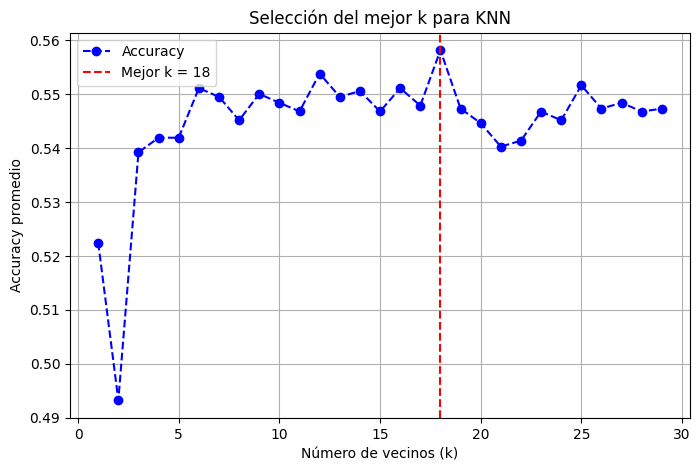

Mejor valor de k: 18 con Accuracy promedio: 0.5582


In [523]:
#Mejor K para Scarosa
# Definir validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Se probo con varios valores de n, pero no se vio una diferencia significativa en los resultados

# Rango de valores de k a evaluar
k_values = range(1, 30)  # Probamos k desde 1 hasta 30, se ve que el rendimiento para mayores k, aumenta pero no significativamente
mean_scores = []

# Evaluar cada valor de k con validación cruzada
for k in k_values:
    pipeline_knn = Pipeline([
        ('scaler', StandardScaler()),  # Escalado dentro de cada fold
        ('model', KNeighborsClassifier(n_neighbors=k))  # Modelo con k vecinos
    ])
    scores = cross_val_score(pipeline_knn, X, y_sacarosa, cv=cv, scoring='accuracy')
    mean_scores.append(np.mean(scores))  # Guardar el promedio de accuracy

# Encontrar el mejor k
best_k = k_values[np.argmax(mean_scores)]
best_score = max(mean_scores)

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(k_values, mean_scores, marker='o', linestyle='dashed', color='b', label='Accuracy')
plt.axvline(best_k, color='r', linestyle='--', label=f'Mejor k = {best_k}')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy promedio')
plt.title('Selección del mejor k para KNN')
plt.legend()
plt.grid()
plt.show()

# Imprimir el mejor k
print(f"Mejor valor de k: {best_k} con Accuracy promedio: {best_score:.4f}")



In [524]:

### 📌 KNN CON EL MEJOR K ###
pipeline_knn_best = Pipeline([
    ('scaler', StandardScaler()),  # Escalar datos
    ('model', KNeighborsClassifier(n_neighbors=best_k))  # Mejor k encontrado
])

# Evaluación con validación cruzada
y_pred_knn = cross_val_predict(pipeline_knn_best, X, y_sacarosa, cv=cv)

# Calcular métricas
print("\n📌 Métricas para sacarosa con KNN con mejor k:")
print(f"Accuracy: {accuracy_score(y_sacarosa, y_pred_knn):.4f}")
print(f"Precisión: {precision_score(y_sacarosa, y_pred_knn, average='macro'):.4f}")
print(f"Recall: {recall_score(y_sacarosa, y_pred_knn, average='macro'):.4f}")
print(f"F1-score: {f1_score(y_sacarosa, y_pred_knn, average='macro'):.4f}")
print("\nReporte de clasificación:\n", classification_report(y_sacarosa, y_pred_knn))


📌 Métricas para sacarosa con KNN con mejor k:
Accuracy: 0.5582
Precisión: 0.5467
Recall: 0.5031
F1-score: 0.5122

Reporte de clasificación:
               precision    recall  f1-score   support

        alto       0.54      0.50      0.52       482
        bajo       0.53      0.30      0.39       429
      normal       0.57      0.70      0.63       936

    accuracy                           0.56      1847
   macro avg       0.55      0.50      0.51      1847
weighted avg       0.55      0.56      0.55      1847



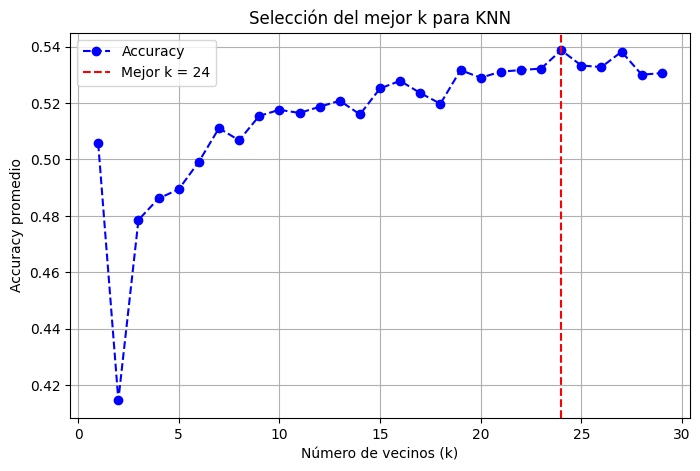

Mejor valor de k: 24 con Accuracy promedio: 0.5387


In [525]:
#Mejor K para TCH
# Definir validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Se probo con varios valores de n, pero no se vio una diferencia significativa en los resultados

# Rango de valores de k a evaluar
k_values = range(1, 30)  # Probamos k desde 1 hasta 30, se ve que el rendimiento para mayores k, queda constante y en algunos vlaores de k desmejora
mean_scores = []

# Evaluar cada valor de k con validación cruzada
for k in k_values:
    pipeline_knn = Pipeline([
        ('scaler', StandardScaler()),  # Escalado dentro de cada fold
        ('model', KNeighborsClassifier(n_neighbors=k))  # Modelo con k vecinos
    ])
    scores = cross_val_score(pipeline_knn, X, y_TCH, cv=cv, scoring='accuracy')
    mean_scores.append(np.mean(scores))  # Guardar el promedio de accuracy

# Encontrar el mejor k
best_k = k_values[np.argmax(mean_scores)]
best_score = max(mean_scores)

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(k_values, mean_scores, marker='o', linestyle='dashed', color='b', label='Accuracy')
plt.axvline(best_k, color='r', linestyle='--', label=f'Mejor k = {best_k}')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy promedio')
plt.title('Selección del mejor k para KNN')
plt.legend()
plt.grid()
plt.show()

# Imprimir el mejor k
print(f"Mejor valor de k: {best_k} con Accuracy promedio: {best_score:.4f}")


In [526]:
### 📌 KNN CON EL MEJOR K ###
pipeline_knn_best = Pipeline([
    ('scaler', StandardScaler()),  # Escalar datos
    ('model', KNeighborsClassifier(n_neighbors=best_k))  # Mejor k encontrado
])

# Evaluación con validación cruzada
y_pred_knn = cross_val_predict(pipeline_knn_best, X, y_TCH, cv=cv)

# Calcular métricas
print("\n📌 Métricas para TCH con KNN con mejor k:")
print(f"Accuracy: {accuracy_score(y_TCH, y_pred_knn):.4f}")
print(f"Precisión: {precision_score(y_TCH, y_pred_knn, average='macro'):.4f}")
print(f"Recall: {recall_score(y_TCH, y_pred_knn, average='macro'):.4f}")
print(f"F1-score: {f1_score(y_TCH, y_pred_knn, average='macro'):.4f}")
print("\nReporte de clasificación:\n", classification_report(y_TCH, y_pred_knn))


📌 Métricas para TCH con KNN con mejor k:
Accuracy: 0.5387
Precisión: 0.4775
Recall: 0.3767
F1-score: 0.3480

Reporte de clasificación:
               precision    recall  f1-score   support

        alto       0.47      0.12      0.19       363
        bajo       0.41      0.11      0.17       490
      normal       0.55      0.91      0.69       994

    accuracy                           0.54      1847
   macro avg       0.48      0.38      0.35      1847
weighted avg       0.50      0.54      0.45      1847



In [527]:
# Regresion Logistica para sacarosa
# Definir validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 📌 SELECCIÓN DEL MEJOR C PARA REGRESIÓN LOGÍSTICA ###
C_values = np.logspace(-4, 1, 10)  # Valores de C desde 0.0001 hasta 10
best_C = None
best_score = 0

for C in C_values:
    pipeline_lr = Pipeline([
        ('scaler', StandardScaler()),  
        ('model',  OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=C)))  
    ])
    scores = cross_val_score(pipeline_lr, X, y_sacarosa, cv=cv, scoring='accuracy')
    mean_score = np.mean(scores)
    
    if mean_score > best_score:
        best_score = mean_score
        best_C = C

print(f"\nMejor valor de C para Regresión Logística: {best_C:.4f} con Accuracy promedio: {best_score:.4f}")



# Pipeline con Regresión Logística y L1
pipeline_lr_best = Pipeline([
    ('scaler', StandardScaler()),  # Escalar datos
    ('model',  OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=best_C)))  # L1 Regularization
])


# Evaluación con validación cruzada
y_pred_lr = cross_val_predict(pipeline_lr_best, X, y_sacarosa, cv=cv)

# Calcular métricas
print("\n📌 Métricas para Regresión Logística para Sacarosa con L1 y mejor C:")
print(f"Accuracy: {accuracy_score(y_sacarosa, y_pred_lr):.4f}")
print(f"Precisión (macro): {precision_score(y_sacarosa, y_pred_lr, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_sacarosa, y_pred_lr, average='macro'):.4f}")
print(f"F1-score (macro): {f1_score(y_sacarosa, y_pred_lr, average='macro'):.4f}")
print("\nReporte de clasificación:\n", classification_report(y_sacarosa, y_pred_lr))

# Entrenar modelo final para obtener coeficientes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model =  OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=best_C))
model.fit(X_scaled, y_sacarosa)


# Imprimir coeficientes de cada clase
print("\nCoeficientes de la Regresión Logística para Sacarosa con L1 y mejor C:")

for i, clf in enumerate(model.estimators_):  # Recorremos los modelos internos
    print(f"\nClase {i}:")
    for j, coef in enumerate(clf.coef_.flatten()):  # Extraemos coeficientes
        print(f"Feature {j + 1}: {coef:.4f}")


Mejor valor de C para Regresión Logística: 0.2154 con Accuracy promedio: 0.5555

📌 Métricas para Regresión Logística para Sacarosa con L1 y mejor C:
Accuracy: 0.5555
Precisión (macro): 0.5657
Recall (macro): 0.4745
F1-score (macro): 0.4873

Reporte de clasificación:
               precision    recall  f1-score   support

        alto       0.55      0.38      0.45       482
        bajo       0.60      0.27      0.37       429
      normal       0.55      0.78      0.65       936

    accuracy                           0.56      1847
   macro avg       0.57      0.47      0.49      1847
weighted avg       0.56      0.56      0.53      1847


Coeficientes de la Regresión Logística para Sacarosa con L1 y mejor C:

Clase 0:
Feature 1: 0.0437
Feature 2: 0.2143
Feature 3: 0.0000
Feature 4: 0.0109
Feature 5: -0.3046
Feature 6: -0.1416
Feature 7: -0.3955
Feature 8: 0.0000
Feature 9: 0.2297
Feature 10: -0.1406
Feature 11: -0.2444
Feature 12: -0.3402
Feature 13: -0.1861
Feature 14: -0.1315
Fea

In [528]:
# Regresion Logistica para TCH
# Definir validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 📌 SELECCIÓN DEL MEJOR C PARA REGRESIÓN LOGÍSTICA ###
C_values = np.logspace(-4, 1, 10)  # Valores de C desde 0.0001 hasta 10
best_C = None
best_score = 0

for C in C_values:
    pipeline_lr = Pipeline([
        ('scaler', StandardScaler()),  
        ('model',  OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=C)))  
    ])
    scores = cross_val_score(pipeline_lr, X, y_TCH, cv=cv, scoring='accuracy')
    mean_score = np.mean(scores)
    
    if mean_score > best_score:
        best_score = mean_score
        best_C = C

print(f"\nMejor valor de C para Regresión Logística: {best_C:.4f} con Accuracy promedio: {best_score:.4f}")



# Pipeline con Regresión Logística y L1
pipeline_lr_best = Pipeline([
    ('scaler', StandardScaler()),  # Escalar datos
     ('model',  OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=best_C)))  # L1 Regularization
])


# Evaluación con validación cruzada
y_pred_lr = cross_val_predict(pipeline_lr_best, X, y_TCH, cv=cv)

# Calcular métricas
print("\n📌 Métricas para Regresión Logística para TCH con L1 y mejor C:")
print(f"Accuracy: {accuracy_score(y_TCH, y_pred_lr):.4f}")
print(f"Precisión (macro): {precision_score(y_TCH, y_pred_lr, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_TCH, y_pred_lr, average='macro'):.4f}")
print(f"F1-score (macro): {f1_score(y_TCH, y_pred_lr, average='macro'):.4f}")
print("\nReporte de clasificación:\n", classification_report(y_TCH, y_pred_lr))

# Entrenar modelo final para obtener coeficientes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model =  OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear', C=best_C))
model.fit(X_scaled, y_TCH)

# Imprimir coeficientes de cada clase
print("\nCoeficientes de la Regresión Logística para SAcarosa con L1 y mejor C:")

for i, clf in enumerate(model.estimators_):  # Recorremos los modelos internos
    print(f"\nClase {i}:")
    for j, coef in enumerate(clf.coef_.flatten()):  # Extraemos coeficientes
        print(f"Feature {j + 1}: {coef:.4f}")


Mejor valor de C para Regresión Logística: 0.0599 con Accuracy promedio: 0.5387

📌 Métricas para Regresión Logística para TCH con L1 y mejor C:
Accuracy: 0.5387
Precisión (macro): 0.4566
Recall (macro): 0.3425
F1-score (macro): 0.2621

Reporte de clasificación:
               precision    recall  f1-score   support

        alto       0.35      0.02      0.04       363
        bajo       0.48      0.02      0.05       490
      normal       0.54      0.98      0.70       994

    accuracy                           0.54      1847
   macro avg       0.46      0.34      0.26      1847
weighted avg       0.49      0.54      0.40      1847


Coeficientes de la Regresión Logística para SAcarosa con L1 y mejor C:

Clase 0:
Feature 1: 0.1323
Feature 2: 0.0000
Feature 3: 0.1715
Feature 4: -0.4518
Feature 5: 0.0000
Feature 6: 0.0000
Feature 7: 0.0584
Feature 8: 0.0000
Feature 9: 0.0000
Feature 10: 0.0000
Feature 11: 0.0000
Feature 12: 0.0687
Feature 13: 0.0000
Feature 14: 0.1052
Feature 15: 0.0

In [539]:
# Regresion Logistica para TCH


# Definir el pipeline con escalado y regresión logística
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de características
    ('classifier', LogisticRegression(penalty='l1',solver='saga', max_iter=50))  # Modelo
])


# Definir los valores a optimizar para C
param_grid = {
    'classifier__C': np.logspace(-4, 4, 10)  # Busca valores de C en escala logarítmica
}

# Definir la validación cruzada con StratifiedShuffleSplit
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Aplicar GridSearchCV para optimizar C
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

# Entrenar el modelo con validación cruzada
grid_search.fit(X, y_TCH)

# Imprimir los mejores parámetros y la mejor puntuación
print(f"Mejor valor de C: {grid_search.best_params_['classifier__C']}")
print(f"Mejor precisión: {grid_search.best_score_:.4f}")


    

Mejor valor de C: 0.3593813663804626
Mejor precisión: 0.5405


In [540]:
X.head()

,dosismad,semsmad,edad,cortes,lluvias,pct_diatrea,me,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,grupo_tenencia_2,grupo_tenencia_3
0,0.8,8.3,12.3,4,137,6.2,12.7,False,False,False,False,False,False,False,False,False,False,True,False,True
1,0.8,6.3,11.2,2,0,3.5,7.8,False,True,False,False,False,False,False,False,False,False,False,False,True
2,0.6,7.9,12.2,3,68,4.3,8.8,False,True,False,False,False,False,False,False,False,False,False,False,True
3,0.8,6.6,13.1,1,0,3.5,6.1,False,True,False,False,False,False,False,False,False,False,False,False,True
4,0.6,8.1,12.2,2,68,4.3,7.9,False,True,False,False,False,False,False,False,False,False,False,False,True
